Per-Class Segmentation and Confusion Analysis.ipynb

In [29]:
!pip install torch torchvision matplotlib scikit-learn opencv-python seaborn


In [28]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns


In [27]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

target_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.PILToTensor()
])

dataset = datasets.OxfordIIITPet(
    root="./data", target_types="segmentation", download=True,
    transform=transform, target_transform=target_transform
)

print("Total samples:", len(dataset))


100%|██████████| 792M/792M [00:29<00:00, 26.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.9MB/s]


Total samples: 3680


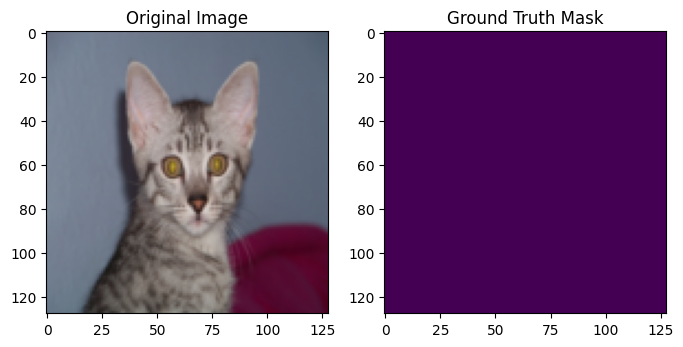

In [30]:
img, mask = random.choice(dataset)
mask = np.array(mask).squeeze()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Ground Truth Mask")
plt.show()


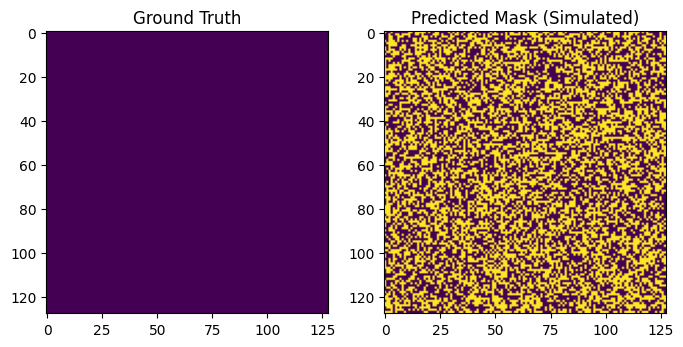

In [31]:
np.random.seed(0)
pred_mask = mask.copy()
noise = np.random.randint(0, 2, mask.shape)
pred_mask = np.abs((mask + noise) % 3)  # 3 classes: background, pet, border

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred_mask)
plt.title("Predicted Mask (Simulated)")
plt.show()


In [32]:
def iou_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / union if union != 0 else 0

def dice_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    return (2. * intersection) / (y_true.sum() + y_pred.sum() + 1e-7)


In [33]:
num_classes = 3  # background, pet, border
iou_per_class = []
dice_per_class = []

for cls in range(num_classes):
    cls_true = (mask == cls)
    cls_pred = (pred_mask == cls)
    iou_per_class.append(iou_score(cls_true, cls_pred))
    dice_per_class.append(dice_score(cls_true, cls_pred))

print("IoU per class:", iou_per_class)
print("Dice per class:", dice_per_class)


IoU per class: [np.float64(0.0), 0, np.float64(0.493896484375)]
Dice per class: [np.float64(0.0), np.float64(0.0), np.float64(0.6612191534537456)]


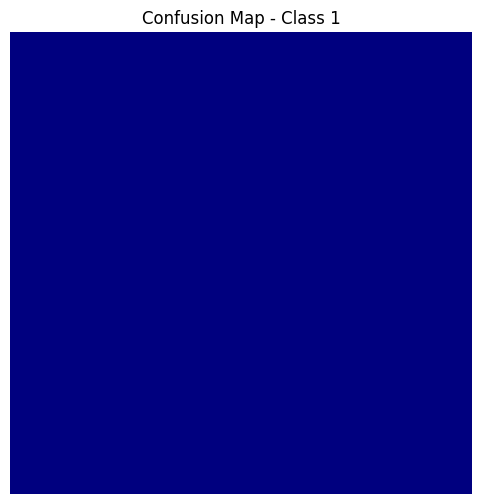

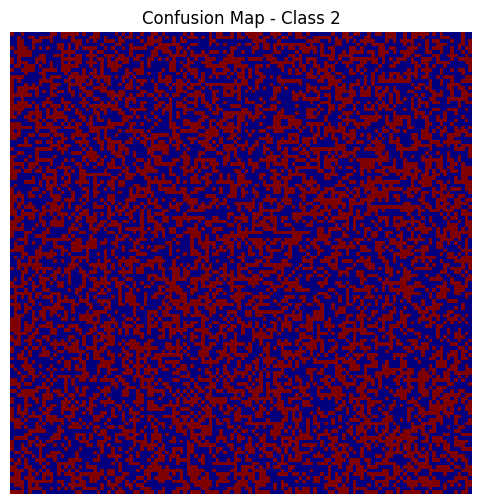

In [34]:
classes_to_check = [1, 2]  # pet and border

for cls in classes_to_check:
    gt = (mask == cls).astype(int)
    pred = (pred_mask == cls).astype(int)

    fp = np.logical_and(pred == 1, gt == 0)
    fn = np.logical_and(pred == 0, gt == 1)
    tp = np.logical_and(pred == 1, gt == 1)

    confusion_map = np.zeros_like(gt, dtype=np.uint8)
    confusion_map[tp] = 2   # green (TP)
    confusion_map[fp] = 3   # red (FP)
    confusion_map[fn] = 1   # blue (FN)

    plt.figure(figsize=(6,6))
    plt.imshow(confusion_map, cmap='jet')
    plt.title(f'Confusion Map - Class {cls}')
    plt.axis('off')
    plt.show()


Reflection:
From the confusion maps of the pet and border classes, I observed that most confusions occur near edges of the animal’s body. The model tends to produce false negatives, missing fine border regions and fur textures. These errors can be reduced by using higher-resolution images, stronger data augmentation (flipping, color jitter), and fine-tuning a model such as U-Net++ or DeepLabV3+ trained longer on the pet segmentation dataset.